### EDA

The goal is to understand which booking characteristics are associated with cancellation risk, therfore our modeling target is:
 `is_canceled` (whether a hotel booking was canceled).


In [4]:
# library imports

from pathlib import Path
import textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display



### Data loading

I used a different working directory, so please adjust the file paths to run the notebook

In [5]:

clean_path = r"C:\Users\Lenovo\Documents\Columbia\Spring 26\machine learning\project\hotel-booking-project-main\data\processed\hotel_bookings_cleaned.csv"
df = pd.read_csv(clean_path)

raw_path = r"C:\Users\Lenovo\Documents\Columbia\Spring 26\machine learning\project\hotel-booking-project-main\data\raw\hotel_bookings_raw.csv"
raw = pd.read_csv(raw_path)

print(f"Cleaned data path: {clean_path}")
print(f"Cleaned shape: {df.shape}")

print(f"Raw data path: {raw_path}")
print(f"Raw shape: {raw.shape}")


Cleaned data path: C:\Users\Lenovo\Documents\Columbia\Spring 26\machine learning\project\hotel-booking-project-main\data\processed\hotel_bookings_cleaned.csv
Cleaned shape: (118563, 40)
Raw data path: C:\Users\Lenovo\Documents\Columbia\Spring 26\machine learning\project\hotel-booking-project-main\data\raw\hotel_bookings_raw.csv
Raw shape: (119390, 32)


In [6]:
display(df.head())
display(pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "non_null": df.notna().sum(),
    "missing": df.isna().sum(),
    "unique": df.nunique(dropna=False)
}).sort_index())

print("Rows:", len(df))
print("Columns:", df.shape[1])


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,reservation_status,reservation_status_date,arrival_date,total_nights,total_guests,is_family,has_agent,has_company,room_changed,is_duplicate_record
0,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,Check-Out,2015-07-02,2015-07-01,1,1,0,0,0,1,0
1,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,Check-Out,2015-07-02,2015-07-01,1,1,0,1,0,0,0
2,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,Check-Out,2015-07-03,2015-07-01,2,2,0,1,0,0,1
3,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,Check-Out,2015-07-03,2015-07-01,2,2,0,1,0,0,1
4,Resort Hotel,0,0,2015,July,27,1,0,2,2,...,Check-Out,2015-07-03,2015-07-01,2,2,0,0,0,0,0


,dtype,non_null,missing,unique
adr,float64,118563,0,8864
adults,int64,118563,0,14
agent,int64,118563,0,334
arrival_date,object,118563,0,793
arrival_date_day_of_month,int64,118563,0,31
arrival_date_month,object,118563,0,12
arrival_date_week_number,int64,118563,0,53
arrival_date_year,int64,118563,0,3
assigned_room_type,object,118563,0,11
babies,int64,118563,0,5


Rows: 118563
Columns: 40


### Target variable

The target is `is_canceled`, where `1` means canceled and `0` means not canceled. A good statistic seems to be the baseline cancellation rate. 


In [7]:
target = "is_canceled"

target_counts = (
    df[target]
    .value_counts()
    .rename_axis("is_canceled")
    .to_frame("count")
)
target_counts["percentage"] = 100 * target_counts["count"] / len(df)

display(target_counts)

print(f"Overall cancellation rate: {df[target].mean():.3%}")


,count,percentage
is_canceled,,
0,74388,62.741327
1,44175,37.258673


Overall cancellation rate: 37.259%


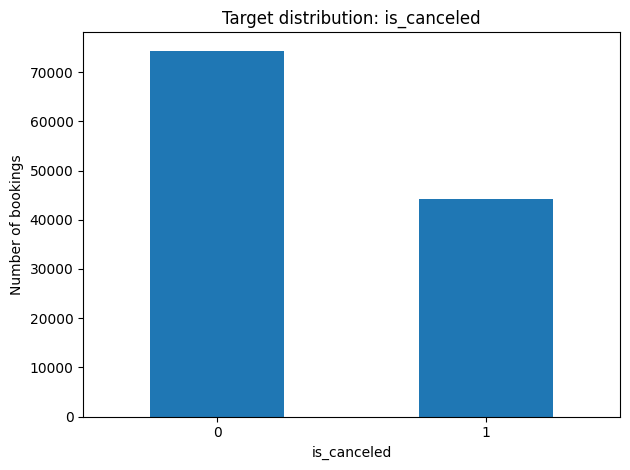

In [8]:
target_counts.sort_index()["count"].plot(kind="bar")
plt.title("Target distribution: is_canceled")
plt.xlabel("is_canceled")
plt.ylabel("Number of bookings")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### Time coverage


The arrival date is useful for seasonality and other time dependent trends. For predictive modeling, we have to be careful to not skew the test/training split on the time axis.

In [9]:
df["arrival_date"] = pd.to_datetime(df["arrival_date"], errors="coerce")
df["reservation_status_date"] = pd.to_datetime(df["reservation_status_date"], errors="coerce")

date_summary = pd.DataFrame({
    "min": [df["arrival_date"].min(), df["reservation_status_date"].min()],
    "max": [df["arrival_date"].max(), df["reservation_status_date"].max()],
    "missing": [df["arrival_date"].isna().sum(), df["reservation_status_date"].isna().sum()]
}, index=["arrival_date", "reservation_status_date"])

display(date_summary)


,min,max,missing
arrival_date,2015-07-01,2017-08-31,0
reservation_status_date,2014-10-17,2017-09-14,0


,bookings,cancel_rate
arrival_date,,
2015-07-01,2754,0.457153
2015-08-01,3863,0.413668
2015-09-01,5098,0.410553
2015-10-01,4916,0.352319
2015-11-01,2313,0.210117


,bookings,cancel_rate
arrival_date,,
2017-04-01,5648,0.435198
2017-05-01,6291,0.438881
2017-06-01,5632,0.432884
2017-07-01,5298,0.374481
2017-08-01,4915,0.369074


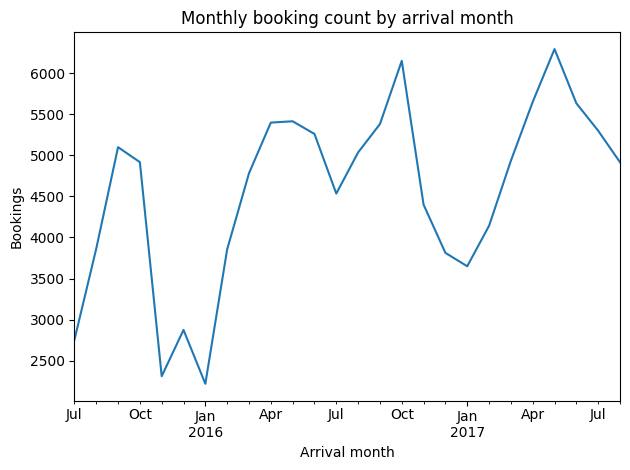

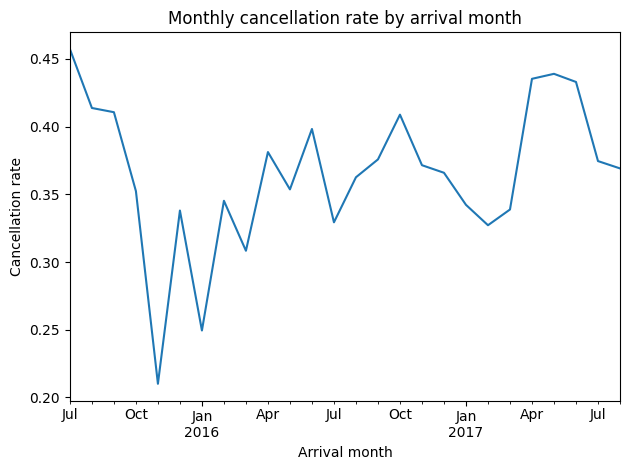

In [10]:
monthly = (
    df
    .set_index("arrival_date")
    .resample("MS")
    .agg(bookings=("is_canceled", "size"), cancel_rate=("is_canceled", "mean"))
)

display(monthly.head())
display(monthly.tail())

monthly["bookings"].plot()
plt.title("Monthly booking count by arrival month")
plt.xlabel("Arrival month")
plt.ylabel("Bookings")
plt.tight_layout()
plt.show()

monthly["cancel_rate"].plot()
plt.title("Monthly cancellation rate by arrival month")
plt.xlabel("Arrival month")
plt.ylabel("Cancellation rate")
plt.tight_layout()
plt.show()


### Data leakage


`reservation_status` can not be legitimate predictor. It already implements the value of our target variable: `Check-Out` means the booking was not canceled, `Canceled` means the booking was canceled, `No-Show` might also mean the booking was canceled.

Thus `reservation_status_date` is also problematic because it records when the above booking status was terminated, again either through 'Check-Out', 'No-Show' or 'Canceled'. That date is only known after the outcome.

#### Questionable variables

Some variables may be known only after an operational change (that might exclude the possibility of a cancellation). So if we want to predict the cancellation risk AT THE TIME OF THE BOOKING, the following variables are problematic:

- `assigned_room_type`: the room assigned may or may not be known at initial booking.
- `room_changed`:  compares reserved and assigned room, so it is also post-booking information.
- `booking_changes`: may occur after initial booking.
- `required_car_parking_spaces` and `total_of_special_requests` may or may not be known at booking time.

The modeling decision depends on the prediction question: At-booking prediction: use only information known immediately when the booking is created. OR Pre-arrival prediction: post-booking updates may be used if they are observed before arrival.


In [11]:
# Direct leakage check: reservation_status vs is_canceled

leakage_table = pd.crosstab(
    df["reservation_status"],
    df["is_canceled"],
    margins=True
)

display(leakage_table)

leakage_rate = (
    df.groupby("reservation_status")["is_canceled"]
      .agg(bookings="count", cancel_rate="mean")
      .sort_values("cancel_rate", ascending=False)
)

display(leakage_rate)


is_canceled,0,1,All
reservation_status,,,
Canceled,0,42982,42982
Check-Out,74388,0,74388
No-Show,0,1193,1193
All,74388,44175,118563


,bookings,cancel_rate
reservation_status,,
Canceled,42982,1.0
No-Show,1193,1.0
Check-Out,74388,0.0


In [12]:
# Post-booking variables: room assignment and booking changes

for col in ["room_changed", "assigned_room_type", "booking_changes"]:
    if col in df.columns:
        summary = (
            df.groupby(col)["is_canceled"]
              .agg(bookings="count", cancel_rate="mean")
              .sort_values("cancel_rate", ascending=False)
        )
        print(f"Cancellation by {col}:")
        display(summary.head(20))


Cancellation by room_changed:


,bookings,cancel_rate
room_changed,,
0,104109,0.416698
1,14454,0.054864


Cancellation by assigned_room_type:


,bookings,cancel_rate
assigned_room_type,,
L,1,1.000000
A,73788,0.446238
H,707,0.355021
G,2532,0.308057
E,7763,0.252609
D,25205,0.252252
F,3728,0.248659
B,2143,0.237984
C,2350,0.189787


Cancellation by booking_changes:


,bookings,cancel_rate
booking_changes,,
16,2,0.500000
0,100714,0.410578
14,3,0.333333
6,60,0.300000
8,14,0.285714
2,3757,0.203354
4,364,0.184066
5,111,0.180180
10,6,0.166667


Going forward it seems best to exlude:

- `reservation_status`
- `reservation_status_date`

For a strict at-booking prediction model, we should also exclude:

- `assigned_room_type`
- `room_changed`
- probably `booking_changes`, unless the prediction is made after booking changes are observed



### The `deposit_type' variable

This is a very suspicious variable. Intuitively, non-refundable bookings should be cancelled less often. But in this dataset `Non Refund` bookings are canceled most of the times!

Even though this does not automatically mean the data is wrong, the variable might nevertheless be entangled somehow. It is also not something that went wrong during the data cleaning process (see below)


In [13]:
def deposit_summary(data):
    out = (
        data.groupby("deposit_type")["is_canceled"]
        .agg(bookings="count", canceled="sum", cancel_rate="mean")
    )
    out["not_canceled"] = out["bookings"] - out["canceled"]
    return out[["bookings", "canceled", "not_canceled", "cancel_rate"]].sort_values("cancel_rate", ascending=False)

print("Cleaned data:")
display(deposit_summary(df))

print("Raw data:")
display(deposit_summary(raw))



Cleaned data:


,bookings,canceled,not_canceled,cancel_rate
deposit_type,,,,
Non Refund,14586,14493,93,0.993624
No Deposit,103815,29646,74169,0.285566
Refundable,162,36,126,0.222222


Raw data:


,bookings,canceled,not_canceled,cancel_rate
deposit_type,,,,
Non Refund,14587,14494,93,0.993624
No Deposit,104641,29694,74947,0.283770
Refundable,162,36,126,0.222222


In [14]:
# Raw-vs-cleaned audit 


non_refund_compare = pd.DataFrame({
    "dataset": ["raw", "cleaned"],
    "non_refund_bookings": [
         (raw["deposit_type"] == "Non Refund").sum(),
         (df["deposit_type"] == "Non Refund").sum()
     ],
     "non_refund_canceled": [
         raw.loc[raw["deposit_type"] == "Non Refund", "is_canceled"].sum(),
          df.loc[df["deposit_type"] == "Non Refund", "is_canceled"].sum()
      ],
      "non_refund_not_canceled": [
          ((raw["deposit_type"] == "Non Refund") & (raw["is_canceled"] == 0)).sum(),
           ((df["deposit_type"] == "Non Refund") & (df["is_canceled"] == 0)).sum()
       ],
       "non_refund_cancel_rate": [
           raw.loc[raw["deposit_type"] == "Non Refund", "is_canceled"].mean(),
           df.loc[df["deposit_type"] == "Non Refund", "is_canceled"].mean()
      ],
    })
display(non_refund_compare)


,dataset,non_refund_bookings,non_refund_canceled,non_refund_not_canceled,non_refund_cancel_rate
0,raw,14587,14494,93,0.993624
1,cleaned,14586,14493,93,0.993624


It seems it might rather have something to with the type of bookings (group bookings and offline TA/To in particular). Maybe there is some hidden administrative process responsible connected with specific booking types that would explain the prevalence of the non-refund cancellations.

In [15]:
# Non Refund bookings by market segment and distribution channel

non_refund = df[df["deposit_type"] == "Non Refund"].copy()

segment_summary = (
    non_refund.groupby(["market_segment", "distribution_channel"])["is_canceled"]
    .agg(bookings="count", canceled="sum", cancel_rate="mean")
    .sort_values("bookings", ascending=False)
)

display(segment_summary.head(20))


bookings  canceled  cancel_rate
market_segment distribution_channel                                 
Groups         TA/TO                     8530      8483     0.994490
Offline TA/TO  TA/TO                     5000      4997     0.999400
Groups         Direct                     374       367     0.981283
               Corporate                  268       260     0.970149
Corporate      Corporate                  256       234     0.914062
               TA/TO                       73        73     1.000000
Online TA      TA/TO                       47        44     0.936170
Direct         Direct                      19        16     0.842105
Online TA      Corporate                    9         9     1.000000
Corporate      Direct                       5         5     1.000000
Offline TA/TO  Corporate                    5         5     1.000000

In [16]:
# Duplicate audit for Non Refund


non_refund_raw = raw[raw["deposit_type"] == "Non Refund"].copy()
exact_duplicate_non_refund = non_refund_raw.duplicated().sum()
unique_non_refund_raw = non_refund_raw.drop_duplicates()

duplicate_audit = pd.DataFrame({
    "quantity": [
        "raw Non Refund rows",
        "exact duplicate Non Refund rows",
        "unique exact Non Refund rows",
        "cancel rate in raw Non Refund rows",
        "cancel rate after exact duplicate drop"
    ],
    "value": [
        len(non_refund_raw),
        exact_duplicate_non_refund,
        len(unique_non_refund_raw),
        non_refund_raw["is_canceled"].mean(),
        unique_non_refund_raw["is_canceled"].mean()
    ]
})
display(duplicate_audit)


,quantity,value
0,raw Non Refund rows,14587.000000
1,exact duplicate Non Refund rows,13549.000000
2,unique exact Non Refund rows,1038.000000
3,cancel rate in raw Non Refund rows,0.993624
4,cancel rate after exact duplicate drop,0.947013


#### It appears best to exclude `deposit_type` from the model for now.

We can later run a model that includes `deposit_type` and compare performance.


### Duplicate records

The cleaned dataset contains duplicate rows and the `is_duplicate_record` flag.

Duplicates inflate the sample size and stability. But repeated rows can possilbly reflect real and genuine repeated transactions, which should not be deleted.



In [17]:
duplicate_summary = pd.DataFrame({
    "metric": [
        "cleaned rows",
        "exact duplicate rows in cleaned data",
        "rows flagged by is_duplicate_record",
        "unique rows after drop_duplicates"
    ],
    "value": [
        len(df),
        df.duplicated().sum(),
        df["is_duplicate_record"].sum() if "is_duplicate_record" in df.columns else np.nan,
        len(df.drop_duplicates())
    ]
})

display(duplicate_summary)

if "is_duplicate_record" in df.columns:
    dup_cancel = (
        df.groupby("is_duplicate_record")["is_canceled"]
          .agg(bookings="count", cancel_rate="mean")
    )
    display(dup_cancel)


,metric,value
0,cleaned rows,118563
1,exact duplicate rows in cleaned data,31926
2,rows flagged by is_duplicate_record,40060
3,unique rows after drop_duplicates,86637


,bookings,cancel_rate
is_duplicate_record,,
0,78503,0.264168
1,40060,0.585047



For modeling, we can use sensitivity checks:

Fist with all cleaned rows. Then with only the exact duplicates dropped. Finally with all duplicate-flagged rows removed.



### Missing values

The cleaned file has no missing values. But actual missing values may have been converted into values such as `0`.

In [18]:
missing = (
    df.isna().sum()
    .to_frame("missing_count")
    .assign(missing_pct=lambda x: 100 * x["missing_count"] / len(df))
    .sort_values("missing_count", ascending=False)
)

display(missing.head(20))

validity_checks = pd.DataFrame({
    "check": [
        "total_nights <= 0",
        "total_guests <= 0",
        "adr < 0",
        "lead_time < 0",
        "children < 0",
        "adults < 0",
        "babies < 0"
    ],
    "count": [
        (df["total_nights"] <= 0).sum(),
        (df["total_guests"] <= 0).sum(),
        (df["adr"] < 0).sum(),
        (df["lead_time"] < 0).sum(),
        (df["children"] < 0).sum(),
        (df["adults"] < 0).sum(),
        (df["babies"] < 0).sum()
    ]
})

display(validity_checks)


,missing_count,missing_pct
hotel,0,0.0
is_canceled,0,0.0
lead_time,0,0.0
arrival_date_year,0,0.0
arrival_date_month,0,0.0
arrival_date_week_number,0,0.0
arrival_date_day_of_month,0,0.0
stays_in_weekend_nights,0,0.0
stays_in_week_nights,0,0.0
adults,0,0.0


,check,count
0,total_nights <= 0,0
1,total_guests <= 0,0
2,adr < 0,0
3,lead_time < 0,0
4,children < 0,0
5,adults < 0,0
6,babies < 0,0


### Numerical Variables


In [19]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Exclude the target from generic numeric summaries where appropriate
numeric_predictors = [c for c in numeric_cols if c != "is_canceled"]

numeric_summary = df[numeric_predictors].describe(
    percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
).T

display(numeric_summary)


,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,95%,99%,max
lead_time,118563.0,104.505655,106.915907,0.0,0.000,0.0,3.0,18.0,70.0,161.0,265.0,320.0,444.0,709.0
arrival_date_year,118563.0,2016.157629,0.707715,2015.0,2015.000,2015.0,2015.0,2016.0,2016.0,2017.0,2017.0,2017.0,2017.0,2017.0
arrival_date_week_number,118563.0,27.157292,13.589311,1.0,2.000,5.0,8.0,16.0,28.0,38.0,45.0,49.0,53.0,53.0
arrival_date_day_of_month,118563.0,15.799609,8.782205,1.0,1.000,2.0,4.0,8.0,16.0,23.0,28.0,30.0,31.0,31.0
stays_in_weekend_nights,118563.0,0.932078,0.995427,0.0,0.000,0.0,0.0,0.0,1.0,2.0,2.0,2.0,4.0,19.0
stays_in_week_nights,118563.0,2.512774,1.893242,0.0,0.000,0.0,1.0,1.0,2.0,3.0,5.0,5.0,10.0,50.0
adults,118563.0,1.860007,0.575446,0.0,1.000,1.0,1.0,2.0,2.0,2.0,2.0,3.0,3.0,55.0
children,118563.0,0.104198,0.399122,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,10.0
babies,118563.0,0.007962,0.097561,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10.0
is_repeated_guest,118563.0,0.029503,0.169213,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0


lead_time: min=0.00, median=70.00, 99th percentile=444.00, max=709.00


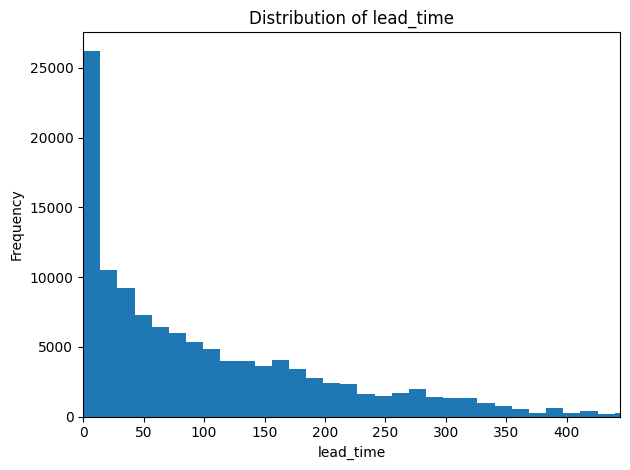

adr: min=0.00, median=95.00, 99th percentile=252.00, max=510.00


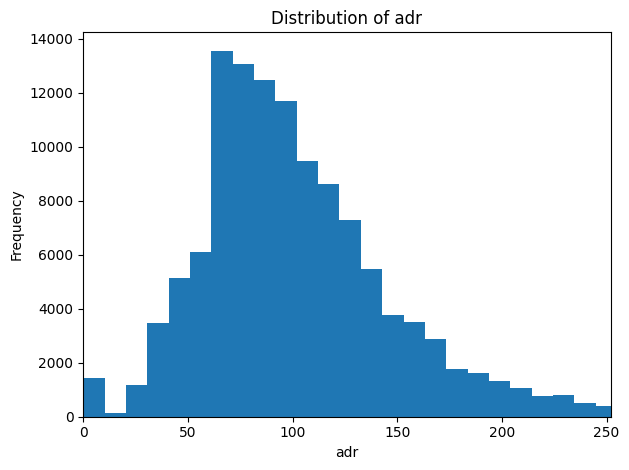

total_nights: min=1.00, median=3.00, 99th percentile=14.00, max=69.00


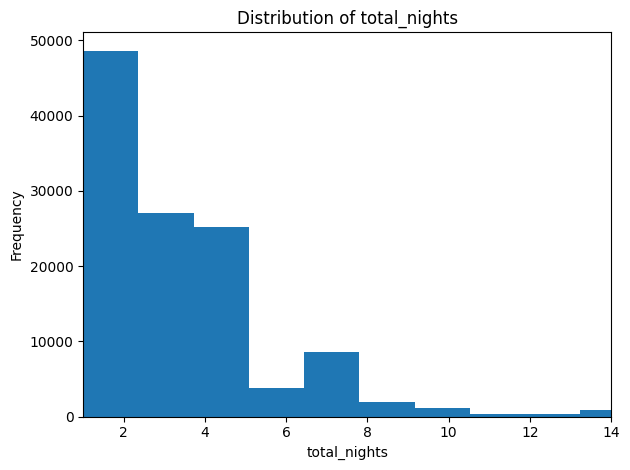

total_guests: min=1.00, median=2.00, 99th percentile=4.00, max=55.00


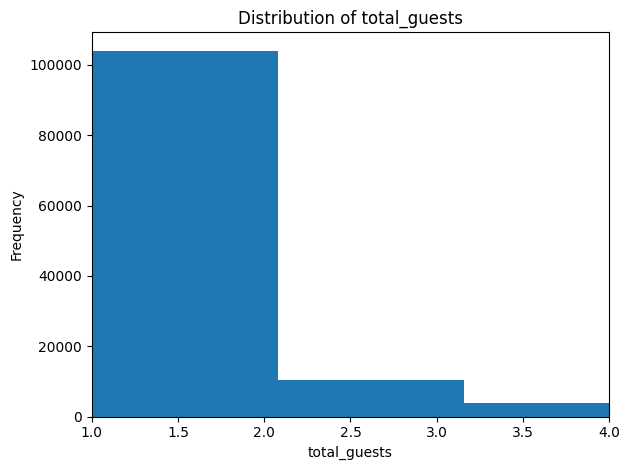

booking_changes: min=0.00, median=0.00, 99th percentile=3.00, max=18.00


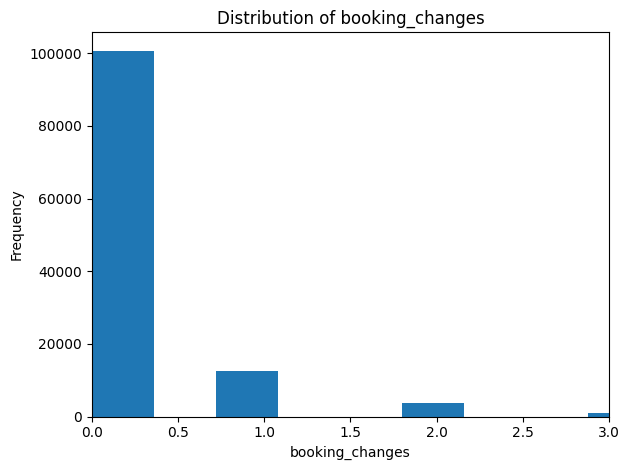

days_in_waiting_list: min=0.00, median=0.00, 99th percentile=75.00, max=391.00


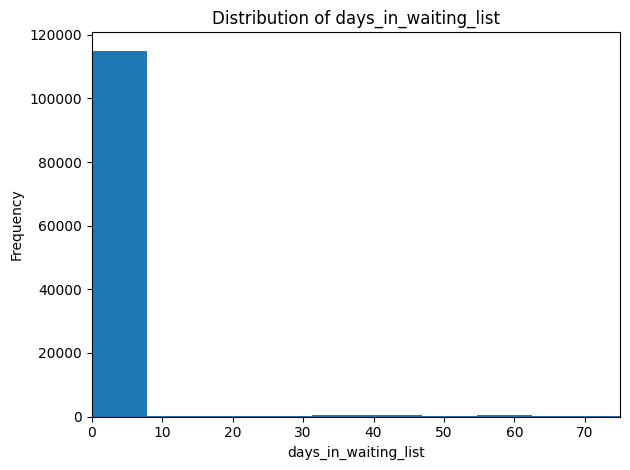

previous_cancellations: min=0.00, median=0.00, 99th percentile=1.00, max=26.00


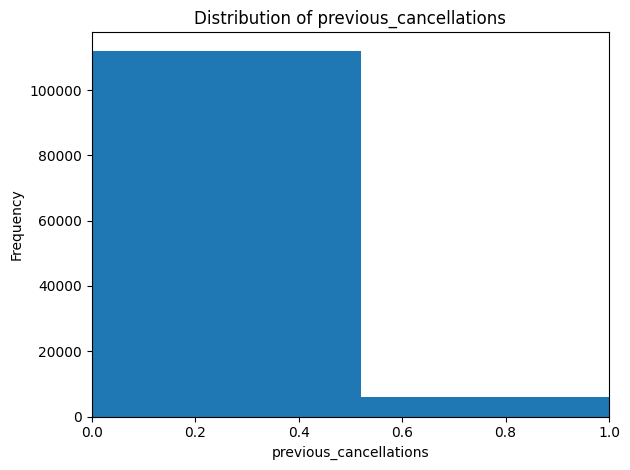

total_of_special_requests: min=0.00, median=0.00, 99th percentile=3.00, max=5.00


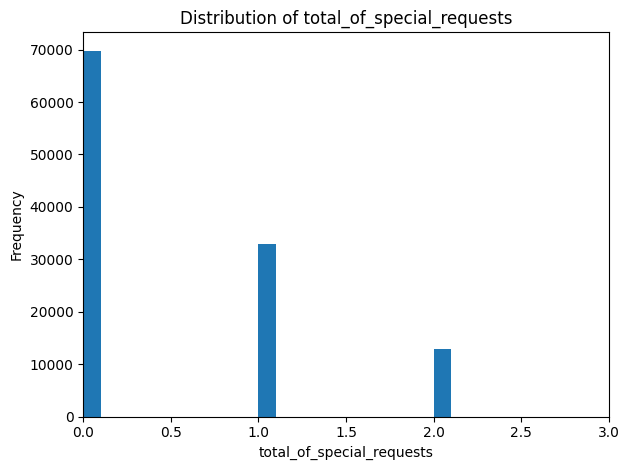

In [20]:

selected_numeric = [
    "lead_time",
    "adr",
    "total_nights",
    "total_guests",
    "booking_changes",
    "days_in_waiting_list",
    "previous_cancellations",
    "total_of_special_requests"
]

for col in selected_numeric:
    if col in df.columns:
        series = df[col].dropna()

        print(f"{col}: min={series.min():,.2f}, median={series.median():,.2f}, "
              f"99th percentile={series.quantile(0.99):,.2f}, max={series.max():,.2f}")

        ax = series.plot(kind="hist", bins=50)
        upper = series.quantile(0.99)

     
        if pd.notna(upper) and upper < series.max():
            ax.set_xlim(series.min(), upper)

        plt.title(f"Distribution of {col}")
        plt.xlabel(col)
        plt.ylabel("Frequency")
        plt.tight_layout()
        plt.show()


Cancellation rate by lead_time bins:


,bookings,canceled,cancel_rate,cancel_rate_pct
lead_time_bin,,,,
0-7,19246,1873,0.097319,9.731892
8-30,18848,5277,0.279977,27.997666
31-90,29436,11136,0.378312,37.831227
91-180,26384,11818,0.447923,44.792298
181-365,21505,11942,0.555313,55.531272
366+,3144,2129,0.677163,67.716285


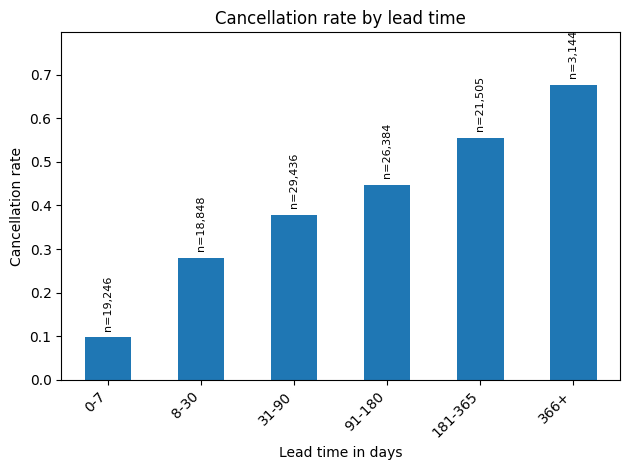

Cancellation rate by adr bins:


,bookings,canceled,cancel_rate,cancel_rate_pct
adr_bin,,,,
≤0,1165,165,0.141631,14.163090
0-50,10023,2331,0.232565,23.256510
50-100,55629,21669,0.389527,38.952705
100-150,35242,13724,0.389422,38.942171
150-200,11576,4395,0.379665,37.966482
200-300,4653,1805,0.387922,38.792177
300+,275,86,0.312727,31.272727


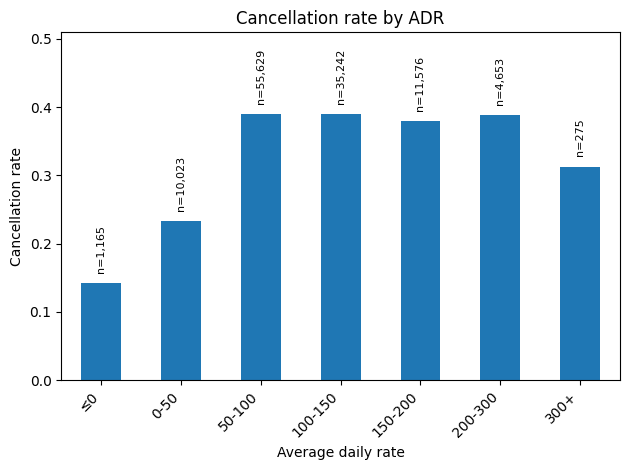

Cancellation rate by total_nights bins:


,bookings,canceled,cancel_rate,cancel_rate_pct
total_nights_bin,,,,
1,21004,5270,0.250905,25.090459
2,27632,12161,0.440106,44.010567
3,27064,11347,0.419265,41.926544
4,17373,6358,0.365970,36.597018
5-7,20265,7161,0.353368,35.336788
8-14,4796,1636,0.341118,34.111760
15+,429,242,0.564103,56.410256


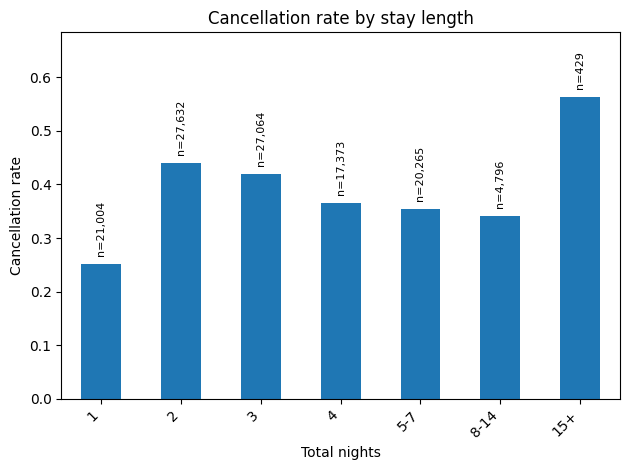

Cancellation rate by total_guests bins:


,bookings,canceled,cancel_rate,cancel_rate_pct
total_guests_bin,,,,
1,22381,6544,0.292391,29.239087
2,81655,32559,0.398739,39.873860
3,10460,3377,0.322849,32.284895
4,3914,1646,0.420542,42.054165
5+,153,49,0.320261,32.026144


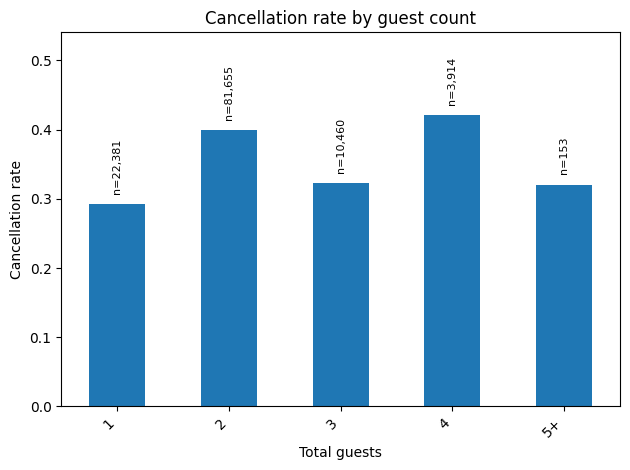

Cancellation rate by days_in_waiting_list bins:


,bookings,canceled,cancel_rate,cancel_rate_pct
waiting_list_bin,,,,
0,114871,41816,0.364026,36.402573
1-7,128,79,0.617188,61.718750
8-30,463,368,0.794816,79.481641
31-90,2137,1395,0.652784,65.278428
91-180,688,382,0.555233,55.523256
181-365,216,81,0.375000,37.500000
366+,60,54,0.900000,90.000000


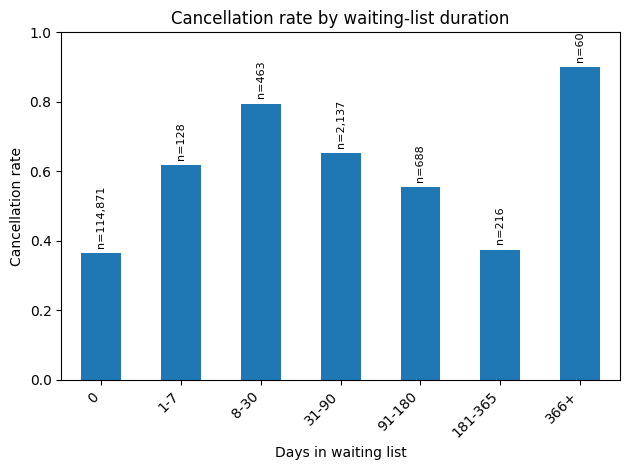

In [21]:
# Cancellation rate by manually binned numeric variables


def make_binned_summary(data, col, bins, labels, bin_col=None):

    if bin_col is None:
        bin_col = f"{col}_bin"

    data[bin_col] = pd.cut(
        data[col],
        bins=bins,
        labels=labels,
        include_lowest=True,
        right=True
    )

    summary = (
        data.groupby(bin_col, observed=True)["is_canceled"]
        .agg(bookings="count", canceled="sum", cancel_rate="mean")
    )

    summary["cancel_rate_pct"] = 100 * summary["cancel_rate"]
    return summary


def plot_binned_cancel_rate(summary, title, xlabel):
    """
    Plot cancellation rate by bin and annotate each bar with the number of bookings.
    """
    plot_data = summary.copy()

    ax = plot_data["cancel_rate"].plot(kind="bar")

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Cancellation rate")
    plt.xticks(rotation=45, ha="right")
    plt.ylim(0, min(1.0, max(0.05, plot_data["cancel_rate"].max() + 0.12)))

    for i, (rate, n) in enumerate(zip(plot_data["cancel_rate"], plot_data["bookings"])):
        if pd.notna(rate):
            plt.text(
                i,
                min(rate + 0.015, 0.98),
                f"n={n:,}",
                ha="center",
                va="bottom",
                rotation=90,
                fontsize=8
            )

    plt.tight_layout()
    plt.show()


bin_specs = {
    "lead_time": {
        "bins": [-1, 7, 30, 90, 180, 365, np.inf],
        "labels": ["0-7", "8-30", "31-90", "91-180", "181-365", "366+"],
        "bin_col": "lead_time_bin",
        "xlabel": "Lead time in days",
        "title": "Cancellation rate by lead time"
    },
    "adr": {
        "bins": [-np.inf, 0, 50, 100, 150, 200, 300, np.inf],
        "labels": ["≤0", "0-50", "50-100", "100-150", "150-200", "200-300", "300+"],
        "bin_col": "adr_bin",
        "xlabel": "Average daily rate",
        "title": "Cancellation rate by ADR"
    },
    "total_nights": {
        "bins": [-1, 0, 1, 2, 3, 4, 7, 14, np.inf],
        "labels": ["0", "1", "2", "3", "4", "5-7", "8-14", "15+"],
        "bin_col": "total_nights_bin",
        "xlabel": "Total nights",
        "title": "Cancellation rate by stay length"
    },
    "total_guests": {
        "bins": [-1, 0, 1, 2, 3, 4, np.inf],
        "labels": ["0", "1", "2", "3", "4", "5+"],
        "bin_col": "total_guests_bin",
        "xlabel": "Total guests",
        "title": "Cancellation rate by guest count"
    },
    "days_in_waiting_list": {
        "bins": [-1, 0, 7, 30, 90, 180, 365, np.inf],
        "labels": ["0", "1-7", "8-30", "31-90", "91-180", "181-365", "366+"],
        "bin_col": "waiting_list_bin",
        "xlabel": "Days in waiting list",
        "title": "Cancellation rate by waiting-list duration"
    },
}

binned_summaries = {}

for col, spec in bin_specs.items():
    if col in df.columns:
        print(f"Cancellation rate by {col} bins:")

        summary = make_binned_summary(
            df,
            col=col,
            bins=spec["bins"],
            labels=spec["labels"],
            bin_col=spec["bin_col"]
        )

        binned_summaries[col] = summary

        display(summary[["bookings", "canceled", "cancel_rate", "cancel_rate_pct"]])
        plot_binned_cancel_rate(
            summary,
            title=spec["title"],
            xlabel=spec["xlabel"]
        )


Some thoughts and observations given above plots:

- `lead_time`: longer lead times usually correspond to higher cancellation risk. This makes sens because there is more time for plans to change.
- `adr`: price is likely confounded with hotel type, season, room type, booking channel, country, and stay length.
- `total_nights`: very short and very long stays may represent different contexts, we should not assume a linear relationship.
- `total_guests`: zero-guest rows are suspicous.
- `previous_cancellations`: heavily skewed.
- `total_of_special_requests`: this may reflect general attitude towards booking and cancellation.



### Categorical variables



In [22]:
categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()
categorical_cols = [c for c in categorical_cols if c not in ["reservation_status_date"]]

cat_overview = pd.DataFrame({
    "column": categorical_cols,
    "n_unique": [df[c].nunique(dropna=False) for c in categorical_cols],
    "top_value": [df[c].value_counts(dropna=False).index[0] for c in categorical_cols],
    "top_count": [df[c].value_counts(dropna=False).iloc[0] for c in categorical_cols],
})
cat_overview["top_pct"] = 100 * cat_overview["top_count"] / len(df)

display(cat_overview.sort_values("n_unique", ascending=False))


,column,n_unique,top_value,top_count,top_pct
3,country,178,PRT,47942,40.435886
1,arrival_date_month,12,August,13812,11.649503
7,assigned_room_type,11,A,73788,62.235267
6,reserved_room_type,9,A,85396,72.025843
4,market_segment,8,Online TA,56129,47.341076
12,adr_bin,7,50-100,55629,46.919359
15,waiting_list_bin,7,0,114871,96.886044
13,total_nights_bin,7,2,27632,23.305753
11,lead_time_bin,6,31-90,29436,24.827307
14,total_guests_bin,5,2,81655,68.870558


In [23]:
def categorical_cancel_summary(data, col, min_count=50, top_n=20):
    out = (
        data.groupby(col, dropna=False)["is_canceled"]
        .agg(bookings="count", cancel_rate="mean")
        .sort_values("bookings", ascending=False)
    )
    out["canceled"] = (out["bookings"] * out["cancel_rate"]).round().astype(int)
    out = out[["bookings", "canceled", "cancel_rate"]]
    return out[out["bookings"] >= min_count].head(top_n)

selected_categorical = [
    "hotel",
    "meal",
    "market_segment",
    "distribution_channel",
    "customer_type",
    "reserved_room_type",
    "assigned_room_type",
    "deposit_type",
    "country"
]

for col in selected_categorical:
    if col in df.columns:
        print(f"Cancellation by {col}:")
        display(categorical_cancel_summary(df, col, min_count=50, top_n=20))


Cancellation by hotel:


,bookings,canceled,cancel_rate
hotel,,,
City Hotel,78898,33065,0.419085
Resort Hotel,39665,11110,0.280096


Cancellation by meal:


,bookings,canceled,cancel_rate
meal,,,
BB,91719,34485,0.375985
HB,14384,4983,0.346427
SC,10503,3943,0.375417
Undefined,1160,286,0.246552
FB,797,478,0.599749


Cancellation by market_segment:


...

,bookings,canceled,cancel_rate
assigned_room_type,,,
A,73788,32927,0.446238
D,25205,6358,0.252252
E,7763,1961,0.252609
F,3728,927,0.248659
G,2532,780,0.308057
C,2350,446,0.189787
B,2143,510,0.237984
H,707,251,0.355021
I,219,4,0.018265


Cancellation by deposit_type:


,bookings,canceled,cancel_rate
deposit_type,,,
No Deposit,103815,29646,0.285566
Non Refund,14586,14493,0.993624
Refundable,162,36,0.222222


Cancellation by country:


,bookings,canceled,cancel_rate
country,,,
PRT,47942,27493,0.573464
GBR,12094,2451,0.202662
FRA,10389,1932,0.185966
ESP,8544,2176,0.254682
DEU,7285,1218,0.167193
ITA,3756,1332,0.354633
IRL,3373,832,0.246665
BEL,2338,473,0.202310
BRA,2217,829,0.373929


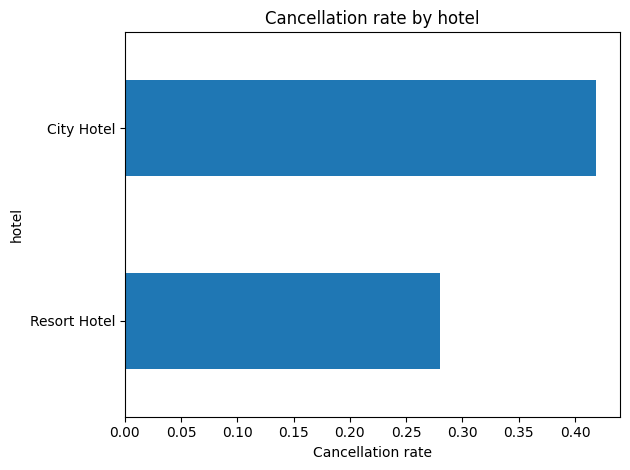

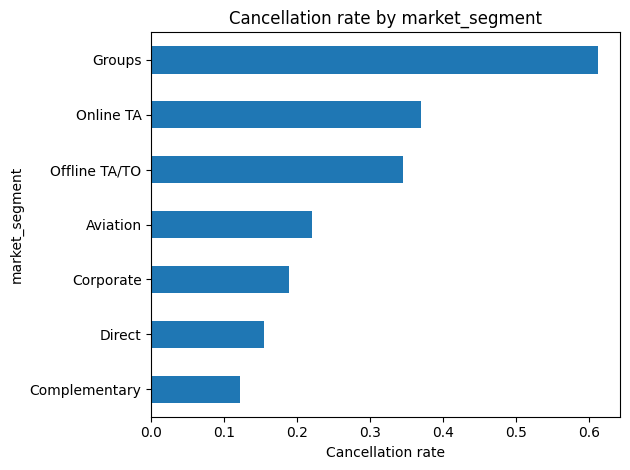

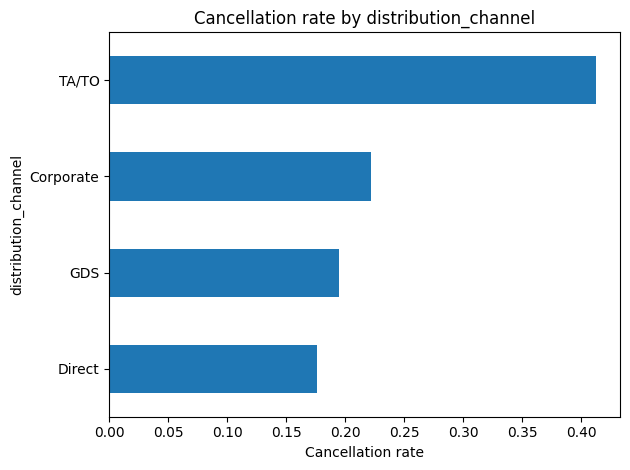

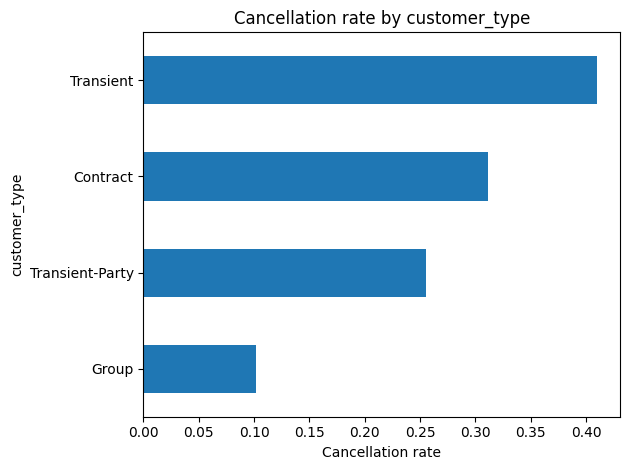

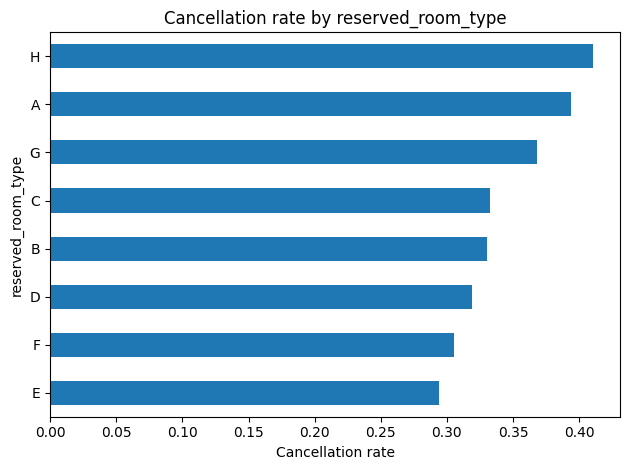

In [24]:
# Plot cancellation rate for selected low-cardinality categorical variables

plot_cats = ["hotel", "market_segment", "distribution_channel", "customer_type", "reserved_room_type"]

for col in plot_cats:
    if col in df.columns:
        out = categorical_cancel_summary(df, col, min_count=50, top_n=15).sort_values("cancel_rate")
        out["cancel_rate"].plot(kind="barh")
        plt.title(f"Cancellation rate by {col}")
        plt.xlabel("Cancellation rate")
        plt.ylabel(col)
        plt.tight_layout()
        plt.show()


## Hotel type

`hotel` is central because City Hotel and Resort Hotel can be assumed to have different demand, seasonality, customer demographic, which may all affect cancellation behavior.

We should therefore not assume one homogeneous hotel population.


,bookings,canceled,cancel_rate
hotel,,,
City Hotel,78898,33065,0.419085
Resort Hotel,39665,11110,0.280096


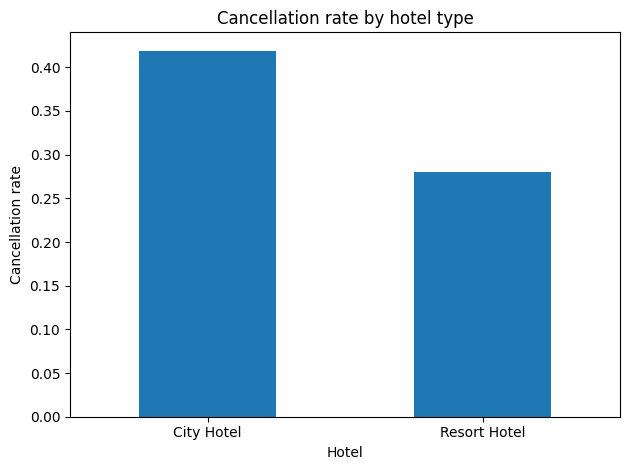

In [25]:
hotel_summary = (
    df.groupby("hotel")["is_canceled"]
    .agg(bookings="count", canceled="sum", cancel_rate="mean")
    .sort_values("cancel_rate", ascending=False)
)

display(hotel_summary)

hotel_summary["cancel_rate"].plot(kind="bar")
plt.title("Cancellation rate by hotel type")
plt.xlabel("Hotel")
plt.ylabel("Cancellation rate")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [26]:
# Hotel type by selected categorical variables

for col in ["market_segment", "customer_type", "deposit_type"]:
    if col in df.columns:
        print(f"Hotel by {col}:")
        display(pd.crosstab(df["hotel"], df[col], normalize="index").round(3))


Hotel by market_segment:


market_segment,Aviation,Complementary,Corporate,Direct,Groups,Offline TA/TO,Online TA,Undefined
hotel,,,,,,,,
City Hotel,0.003,0.007,0.038,0.076,0.177,0.211,0.489,0.0
Resort Hotel,0.000,0.005,0.057,0.162,0.146,0.187,0.443,0.0


Hotel by customer_type:


customer_type,Contract,Group,Transient,Transient-Party
hotel,,,,
City Hotel,0.029,0.004,0.748,0.219
Resort Hotel,0.045,0.007,0.754,0.195


Hotel by deposit_type:


deposit_type,No Deposit,Non Refund,Refundable
hotel,,,
City Hotel,0.837,0.163,0.000
Resort Hotel,0.953,0.043,0.004


### Lead time

Longer lead times mean more opportunity for plans to change, and they may also reflect different booking channels or customer types.


,bookings,canceled,cancel_rate
lead_time_bin,,,
0-7,19246,1873,0.097319
8-30,18848,5277,0.279977
31-90,29436,11136,0.378312
91-180,26384,11818,0.447923
181-365,21505,11942,0.555313
366+,3144,2129,0.677163


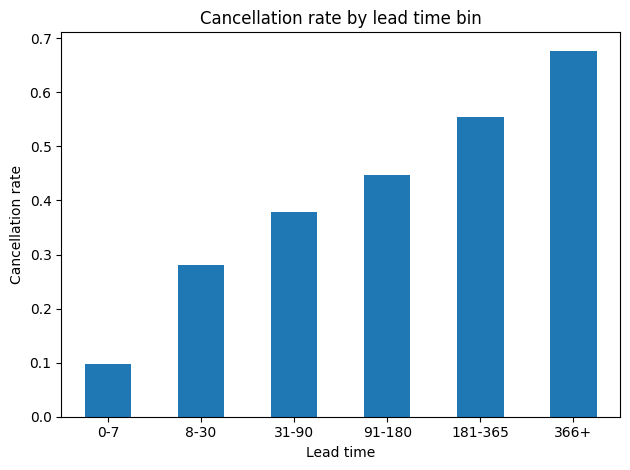

In [27]:
df["lead_time_bin"] = pd.cut(
    df["lead_time"],
    bins=[-1, 7, 30, 90, 180, 365, np.inf],
    labels=["0-7", "8-30", "31-90", "91-180", "181-365", "366+"]
)

lead_summary = (
    df.groupby("lead_time_bin", observed=True)["is_canceled"]
    .agg(bookings="count", canceled="sum", cancel_rate="mean")
)

display(lead_summary)

lead_summary["cancel_rate"].plot(kind="bar")
plt.title("Cancellation rate by lead time bin")
plt.xlabel("Lead time")
plt.ylabel("Cancellation rate")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


,hotel,lead_time_bin,bookings,cancel_rate
0,City Hotel,0-7,10511,0.123299
1,City Hotel,8-30,12511,0.309967
2,City Hotel,31-90,20747,0.399865
3,City Hotel,91-180,18200,0.480440
4,City Hotel,181-365,14226,0.627654
5,City Hotel,366+,2703,0.711062
6,Resort Hotel,0-7,8735,0.066056
7,Resort Hotel,8-30,6337,0.220767
8,Resort Hotel,31-90,8689,0.326850
9,Resort Hotel,91-180,8184,0.375611


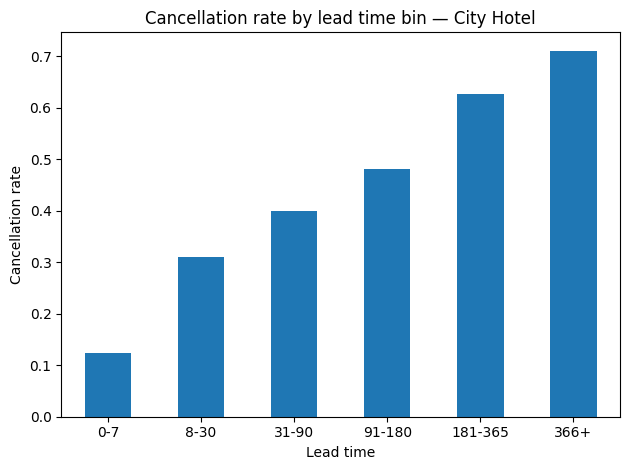

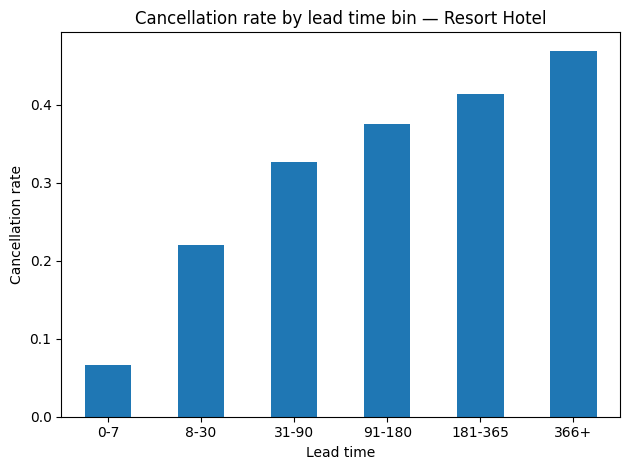

In [28]:
# Lead time by hotel

lead_hotel = (
    df.groupby(["hotel", "lead_time_bin"], observed=True)["is_canceled"]
    .agg(bookings="count", cancel_rate="mean")
    .reset_index()
)

display(lead_hotel)

for hotel_name, sub in lead_hotel.groupby("hotel"):
    sub = sub.set_index("lead_time_bin")
    sub["cancel_rate"].plot(kind="bar")
    plt.title(f"Cancellation rate by lead time bin — {hotel_name}")
    plt.xlabel("Lead time")
    plt.ylabel("Cancellation rate")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()


### Guest composition and stay length

Variables such as `adults`, `children`, `babies`, `total_guests`, `is_family`, and `total_nights` describe the booking party and trip structure.


In [29]:
guest_cols = ["adults", "children", "babies", "total_guests", "is_family", "total_nights"]

for col in guest_cols:
    if col in df.columns:
        print(f"Cancellation by {col}:")
        summary = (
            df.groupby(col)["is_canceled"]
              .agg(bookings="count", cancel_rate="mean")
              .sort_index()
        )
        display(summary.head(30))


Cancellation by adults:


,bookings,cancel_rate
adults,,
0,223,0.376682
1,22825,0.291917
2,89251,0.394898
3,6186,0.347721
4,62,0.258065
5,2,1.000000
6,1,1.000000
10,1,1.000000
20,2,1.000000


Cancellation by children:


,bookings,cancel_rate
children,,
0,110007,0.373149
1,4842,0.323627
2,3637,0.423701
3,76,0.223684
10,1,1.000000


Cancellation by babies:


...

,bookings,cancel_rate
total_guests,,
1,22381,0.292391
2,81655,0.398739
3,10460,0.322849
4,3914,0.420542
5,136,0.250000
6,1,1.000000
10,2,0.500000
12,2,0.500000
20,2,1.000000


Cancellation by is_family:


,bookings,cancel_rate
is_family,,
0,109270,0.374449
1,9293,0.350694


Cancellation by total_nights:


,bookings,cancel_rate
total_nights,,
1,21004,0.250905
2,27632,0.440106
3,27064,0.419265
4,17373,0.365970
5,7771,0.342556
6,3846,0.397816
7,8648,0.343316
8,1155,0.381818
9,840,0.372619


,bookings,canceled,cancel_rate,cancel_rate_pct
total_nights_bin,,,,
1,21004,5270,0.250905,25.090459
2,27632,12161,0.440106,44.010567
3,27064,11347,0.419265,41.926544
4,17373,6358,0.365970,36.597018
5-7,20265,7161,0.353368,35.336788
8-14,4796,1636,0.341118,34.111760
15+,429,242,0.564103,56.410256


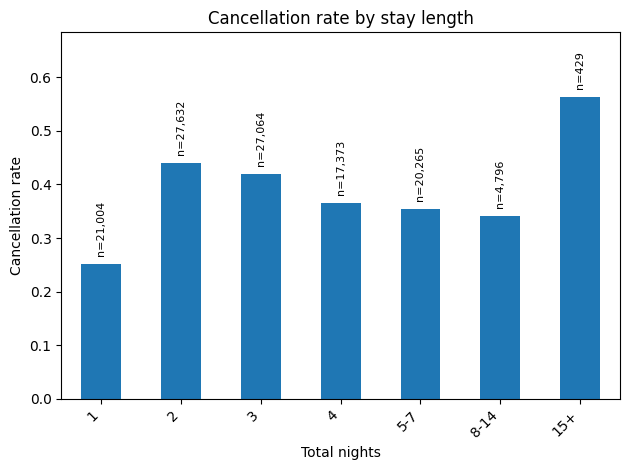

In [30]:
# Stay length bins

# Reuse the  total_nights_bin from the numeric binning section.

if "total_nights_bin" not in df.columns:
    df["total_nights_bin"] = pd.cut(
        df["total_nights"],
        bins=[-1, 0, 1, 2, 3, 4, 7, 14, np.inf],
        labels=["0", "1", "2", "3", "4", "5-7", "8-14", "15+"],
        include_lowest=True,
        right=True
    )

stay_summary = (
    df.groupby("total_nights_bin", observed=True)["is_canceled"]
    .agg(bookings="count", canceled="sum", cancel_rate="mean")
)

stay_summary["cancel_rate_pct"] = 100 * stay_summary["cancel_rate"]

display(stay_summary)

plot_binned_cancel_rate(
    stay_summary,
    title="Cancellation rate by stay length",
    xlabel="Total nights"
)


### ADR

`adr` is average daily rate and is entangled with many other variables: hotel type, season, room type, booking channel, stay length, country.


In [31]:
adr_summary = df["adr"].describe(
    percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
).to_frame("adr")

display(adr_summary)

print("ADR == 0:", (df["adr"] == 0).sum())
print("ADR < 0:", (df["adr"] < 0).sum())
print("ADR > 1000:", (df["adr"] > 1000).sum())


,adr
count,118563.000000
mean,102.480047
std,47.579382
min,0.000000
1%,1.924000
5%,40.000000
10%,52.000000
25%,70.000000
50%,95.000000
75%,126.000000


ADR == 0: 1165
ADR < 0: 0
ADR > 1000: 0


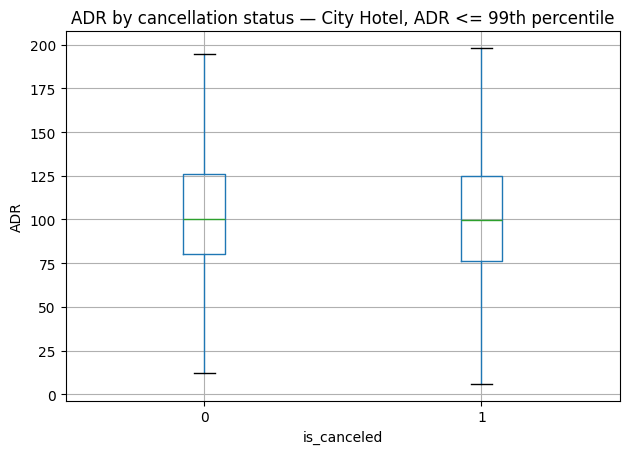

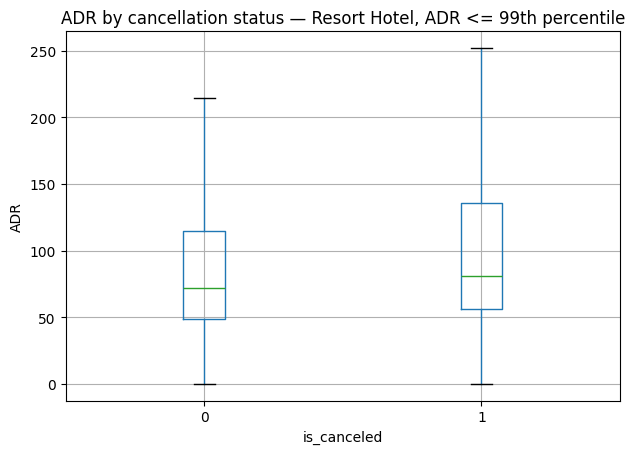

In [32]:
adr_upper = df["adr"].quantile(0.99)

for hotel_name, sub in df.groupby("hotel"):
    sub_zoom = sub[sub["adr"] <= adr_upper]

    sub_zoom.boxplot(
        column="adr",
        by="is_canceled",
        showfliers=False
    )
    plt.title(f"ADR by cancellation status — {hotel_name}, ADR <= 99th percentile")
    plt.suptitle("")
    plt.xlabel("is_canceled")
    plt.ylabel("ADR")
    plt.tight_layout()
    plt.show()

### Special requests, parking, and repeated guests

These variables might have strong associations with cancellation.

More special requests may indicate a more committed guest, but it may also reflect channel/system behavior. Parking-space requests are extremely predictive in this dataset. (We need to check whether the variable is available at booking time and whether it behaves plausibly.) Repeated guests often cancel less.


In [33]:
behavior_cols = [
    "total_of_special_requests",
    "required_car_parking_spaces",
    "is_repeated_guest",
    "previous_cancellations",
    "previous_bookings_not_canceled",
    "booking_changes",
    "days_in_waiting_list"
]

for col in behavior_cols:
    if col in df.columns:
        print(f"Cancellation by {col}:")

        summary = (
            df.groupby(col)["is_canceled"]
            .agg(bookings="count", canceled="sum", cancel_rate="mean")
            .sort_index()
        )

        summary["cancel_rate_pct"] = 100 * summary["cancel_rate"]

        # Display all rows for compact variables, otherwise show the first 30 levels.
        if summary.shape[0] <= 30:
            display(summary)
        else:
            display(summary.head(30))
            print(f"... {summary.shape[0] - 30} additional levels not displayed.")


Cancellation by total_of_special_requests:


,bookings,canceled,cancel_rate,cancel_rate_pct
total_of_special_requests,,,,
0,69798,33520,0.480243,48.024299
1,33005,7307,0.221391,22.139070
2,12894,2865,0.222196,22.219637
3,2486,445,0.179002,17.900241
4,340,36,0.105882,10.588235
5,40,2,0.050000,5.000000


Cancellation by required_car_parking_spaces:


,bookings,canceled,cancel_rate,cancel_rate_pct
required_car_parking_spaces,,,,
0,111170,44175,0.397364,39.73644
1,7360,0,0.000000,0.00000
2,28,0,0.000000,0.00000
3,3,0,0.000000,0.00000
8,2,0,0.000000,0.00000


Cancellation by is_repeated_guest:


...

... 43 additional levels not displayed.
Cancellation by booking_changes:


,bookings,canceled,cancel_rate,cancel_rate_pct
booking_changes,,,,
0,100714,41351,0.410578,41.057847
1,12573,1800,0.143164,14.316392
2,3757,764,0.203354,20.335374
3,910,144,0.158242,15.824176
4,364,67,0.184066,18.406593
5,111,20,0.180180,18.018018
6,60,18,0.300000,30.000000
7,28,3,0.107143,10.714286
8,14,4,0.285714,28.571429


Cancellation by days_in_waiting_list:


,bookings,canceled,cancel_rate,cancel_rate_pct
days_in_waiting_list,,,,
0,114871,41816,0.364026,36.402573
1,12,3,0.250000,25.000000
2,5,1,0.200000,20.000000
3,59,59,1.000000,100.000000
4,25,8,0.320000,32.000000
5,8,5,0.625000,62.500000
6,15,0,0.000000,0.000000
7,4,3,0.750000,75.000000
8,7,4,0.571429,57.142857


... 97 additional levels not displayed.


Grouped cancellation summary for total_of_special_requests:


,bookings,canceled,cancel_rate,cancel_rate_pct
special_requests_bin,,,,
0,69798,33520,0.480243,48.024299
1,33005,7307,0.221391,22.139070
2,12894,2865,0.222196,22.219637
3,2486,445,0.179002,17.900241
4,340,36,0.105882,10.588235
5+,40,2,0.050000,5.000000


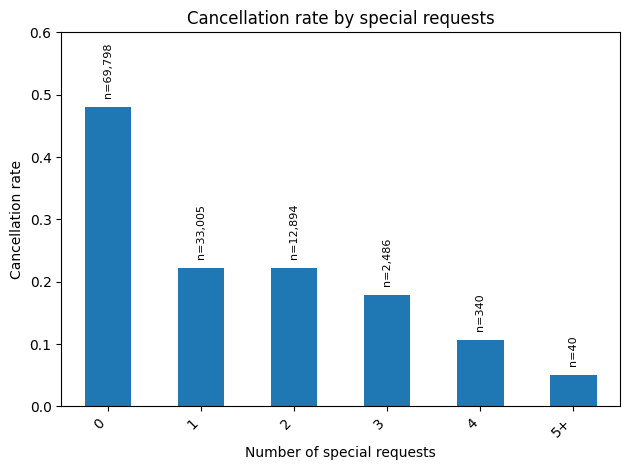

Grouped cancellation summary for required_car_parking_spaces:


,bookings,canceled,cancel_rate,cancel_rate_pct
parking_spaces_bin,,,,
0,111170,44175,0.397364,39.73644
1,7360,0,0.000000,0.00000
2+,33,0,0.000000,0.00000


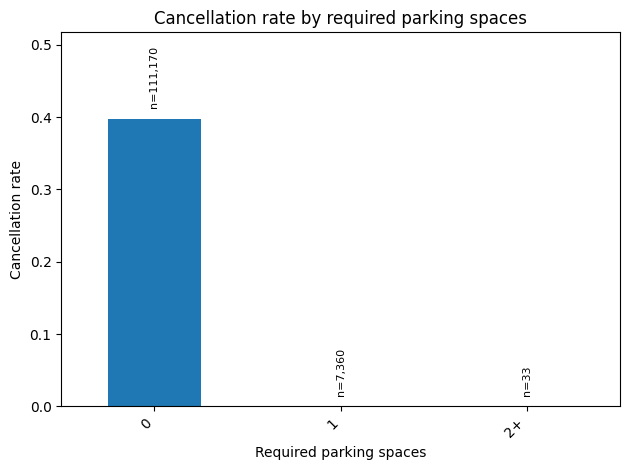

Grouped cancellation summary for previous_cancellations:


,bookings,canceled,cancel_rate,cancel_rate_pct
previous_cancellations_bin,,,,
0,112088,38235,0.341116,34.111591
1,6044,5712,0.945069,94.506949
2,114,38,0.333333,33.333333
3,65,20,0.307692,30.769231
4+,252,170,0.674603,67.460317


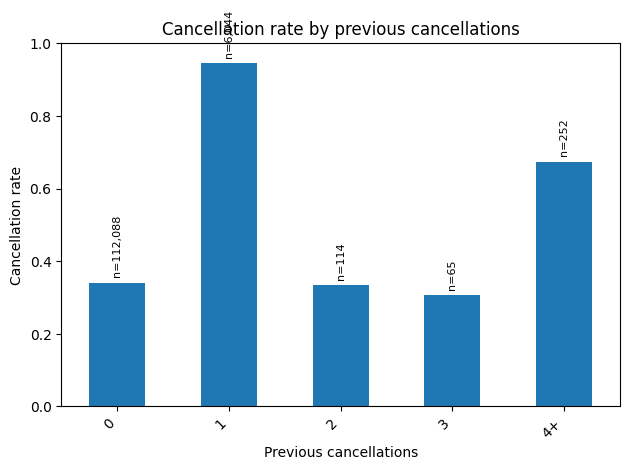

Grouped cancellation summary for previous_bookings_not_canceled:


,bookings,canceled,cancel_rate,cancel_rate_pct
previous_not_canceled_bin,,,,
0,114981,43976,0.382463,38.246319
1,1520,78,0.051316,5.131579
2,575,32,0.055652,5.565217
3-5,737,40,0.054274,5.427408
6-10,383,18,0.046997,4.699739
11+,367,31,0.084469,8.446866


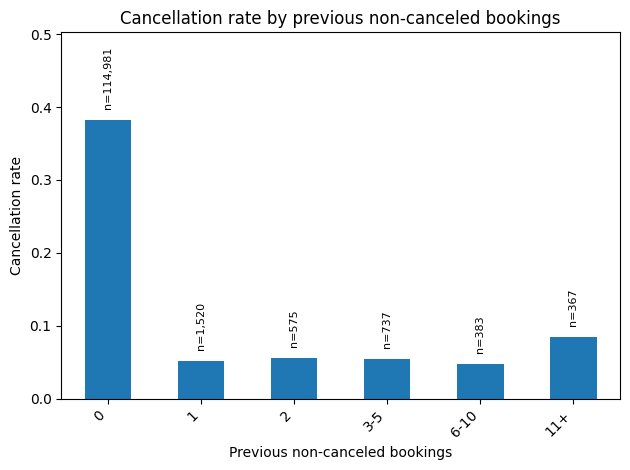

,bookings,canceled,cancel_rate,cancel_rate_pct
is_repeated_guest,,,,
0,115065,43626,0.379142,37.914222
1,3498,549,0.156947,15.694683


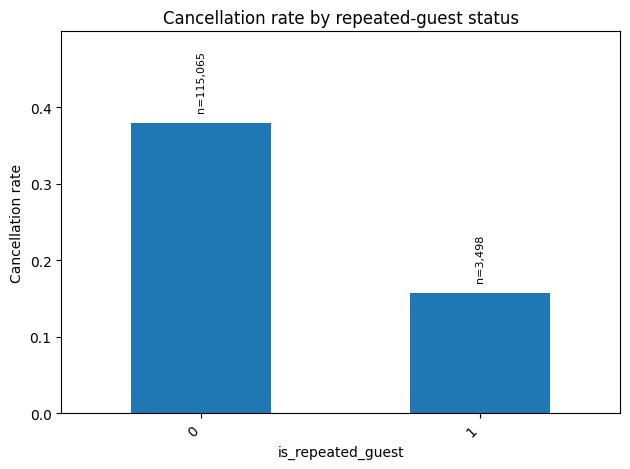

In [34]:
# Compact, interpretable behavior-variable plots

# Use manual grouping for sparse count variables instead of plotting every possible value.

behavior_bin_specs = {
    "total_of_special_requests": {
        "bins": [-1, 0, 1, 2, 3, 4, np.inf],
        "labels": ["0", "1", "2", "3", "4", "5+"],
        "bin_col": "special_requests_bin",
        "xlabel": "Number of special requests",
        "title": "Cancellation rate by special requests"
    },
    "required_car_parking_spaces": {
        "bins": [-1, 0, 1, np.inf],
        "labels": ["0", "1", "2+"],
        "bin_col": "parking_spaces_bin",
        "xlabel": "Required parking spaces",
        "title": "Cancellation rate by required parking spaces"
    },
    "previous_cancellations": {
        "bins": [-1, 0, 1, 2, 3, np.inf],
        "labels": ["0", "1", "2", "3", "4+"],
        "bin_col": "previous_cancellations_bin",
        "xlabel": "Previous cancellations",
        "title": "Cancellation rate by previous cancellations"
    },
    "previous_bookings_not_canceled": {
        "bins": [-1, 0, 1, 2, 5, 10, np.inf],
        "labels": ["0", "1", "2", "3-5", "6-10", "11+"],
        "bin_col": "previous_not_canceled_bin",
        "xlabel": "Previous non-canceled bookings",
        "title": "Cancellation rate by previous non-canceled bookings"
    },
}

for col, spec in behavior_bin_specs.items():
    if col in df.columns:
        print(f"Grouped cancellation summary for {col}:")

        summary = make_binned_summary(
            df,
            col=col,
            bins=spec["bins"],
            labels=spec["labels"],
            bin_col=spec["bin_col"]
        )

        display(summary[["bookings", "canceled", "cancel_rate", "cancel_rate_pct"]])

        plot_binned_cancel_rate(
            summary,
            title=spec["title"],
            xlabel=spec["xlabel"]
        )

# Binary repeated-guest plot, kept as exact categories.
if "is_repeated_guest" in df.columns:
    repeated_guest_summary = (
        df.groupby("is_repeated_guest")["is_canceled"]
        .agg(bookings="count", canceled="sum", cancel_rate="mean")
    )
    repeated_guest_summary["cancel_rate_pct"] = 100 * repeated_guest_summary["cancel_rate"]

    display(repeated_guest_summary)

    plot_binned_cancel_rate(
        repeated_guest_summary,
        title="Cancellation rate by repeated-guest status",
        xlabel="is_repeated_guest"
    )


### Market segment and distribution channel

These variables might help explain why `deposit_type` is suspicious, because the `Non Refund` rows are heavily concentrated in group and offline travel-agent/tour-operator channels.

These variables are probably valid at booking time, but they also may make a model strongly dependent on this particular hotel dataset's business process.


In [35]:
segment_channel = (
    df.groupby(["market_segment", "distribution_channel"])["is_canceled"]
    .agg(bookings="count", canceled="sum", cancel_rate="mean")
    .sort_values("bookings", ascending=False)
)

display(segment_channel.head(30))

# Normalize counts by cancellation status
display(pd.crosstab(df["market_segment"], df["is_canceled"], normalize="index").round(3))
display(pd.crosstab(df["distribution_channel"], df["is_canceled"], normalize="index").round(3))


bookings  canceled  cancel_rate
market_segment distribution_channel                                 
Online TA      TA/TO                    55813     20670     0.370344
Offline TA/TO  TA/TO                    23776      8186     0.344297
Groups         TA/TO                    17088     11153     0.652680
Direct         Direct                   12122      1909     0.157482
Corporate      Corporate                 4728       876     0.185279
Groups         Direct                    1457       543     0.372684
               Corporate                 1213       397     0.327288
Complementary  Direct                     557        68     0.122083
Corporate      TA/TO                      333        95     0.285285
Direct         TA/TO                      236        10     0.042373
Aviation       Corporate                  221        50     0.226244
Offline TA/TO  Corporate                  211       103     0.488152
Corporate      Direct                     170        18     0.105882
Online TA      GDS                        144        29     0.201389
               Direct                     128         9     0.070312
Direct         Corporate                   88        10     0.113636
Complementary  Corporate                   80        12     0.150000
               TA/TO                       78         7     0.089744
Offline TA/TO  GDS                         45         8     0.177778
Online TA      Corporate                   43        14     0.325581
Offline TA/TO  Direct                      16         3     0.187500
Aviation       TA/TO                       10         1     0.100000
Undefined      Undefined                    2         2     1.000000
Direct         Undefined                    2         1     0.500000
               GDS                          1         0     0.000000
Online TA      Undefined                    1         1     1.000000

is_canceled,0,1
market_segment,,
Aviation,0.779,0.221
Complementary,0.878,0.122
Corporate,0.811,0.189
Direct,0.845,0.155
Groups,0.388,0.612
Offline TA/TO,0.655,0.345
Online TA,0.631,0.369
Undefined,0.000,1.000


is_canceled,0,1
distribution_channel,,
Corporate,0.778,0.222
Direct,0.824,0.176
GDS,0.805,0.195
TA/TO,0.588,0.412
Undefined,0.200,0.800


In [36]:
# Market segment by deposit type

display(pd.crosstab(df["market_segment"], df["deposit_type"]))
display(pd.crosstab(df["market_segment"], df["deposit_type"], normalize="index").round(3))


deposit_type,No Deposit,Non Refund,Refundable
market_segment,,,
Aviation,231,0,0
Complementary,715,0,0
Corporate,4893,334,4
Direct,12424,19,6
Groups,10456,9172,130
Offline TA/TO,19039,5005,4
Online TA,56055,56,18
Undefined,2,0,0


deposit_type,No Deposit,Non Refund,Refundable
market_segment,,,
Aviation,1.000,0.000,0.000
Complementary,1.000,0.000,0.000
Corporate,0.935,0.064,0.001
Direct,0.998,0.002,0.000
Groups,0.529,0.464,0.007
Offline TA/TO,0.792,0.208,0.000
Online TA,0.999,0.001,0.000
Undefined,1.000,0.000,0.000


### Country

This variable can be predictive, but it can also lead to overfitting.

,bookings,canceled,cancel_rate
country,,,
PRT,47942,27493,0.573464
GBR,12094,2451,0.202662
FRA,10389,1932,0.185966
ESP,8544,2176,0.254682
DEU,7285,1218,0.167193
ITA,3756,1332,0.354633
IRL,3373,832,0.246665
BEL,2338,473,0.202310
BRA,2217,829,0.373929


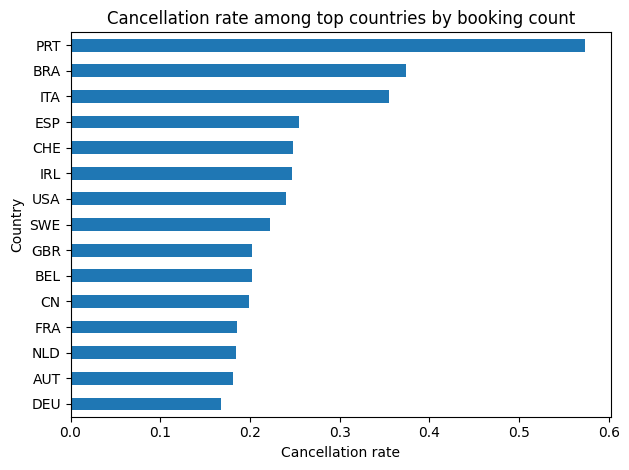

In [37]:
country_summary = (
    df.groupby("country")["is_canceled"]
    .agg(bookings="count", canceled="sum", cancel_rate="mean")
    .sort_values("bookings", ascending=False)
)

display(country_summary.head(25))

top_countries = country_summary.head(15).sort_values("cancel_rate")
top_countries["cancel_rate"].plot(kind="barh")
plt.title("Cancellation rate among top countries by booking count")
plt.xlabel("Cancellation rate")
plt.ylabel("Country")
plt.tight_layout()
plt.show()


What's up with Portugal?!

### Correlation (numeric variables)



,correlation_with_is_canceled
lead_time,0.291532
previous_cancellations,0.109975
has_agent,0.101078
adults,0.057574
days_in_waiting_list,0.053942
total_guests,0.044237
adr,0.040142
stays_in_week_nights,0.020725
arrival_date_year,0.015448
total_nights,0.013582


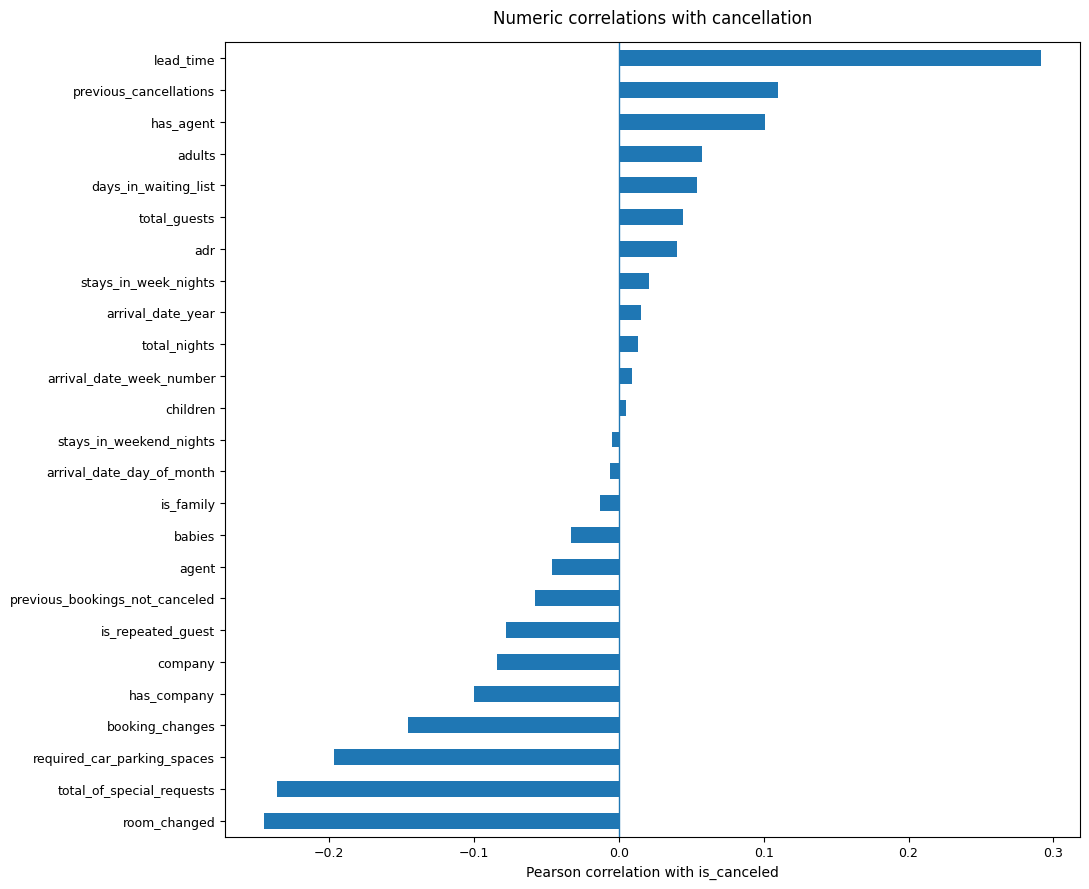

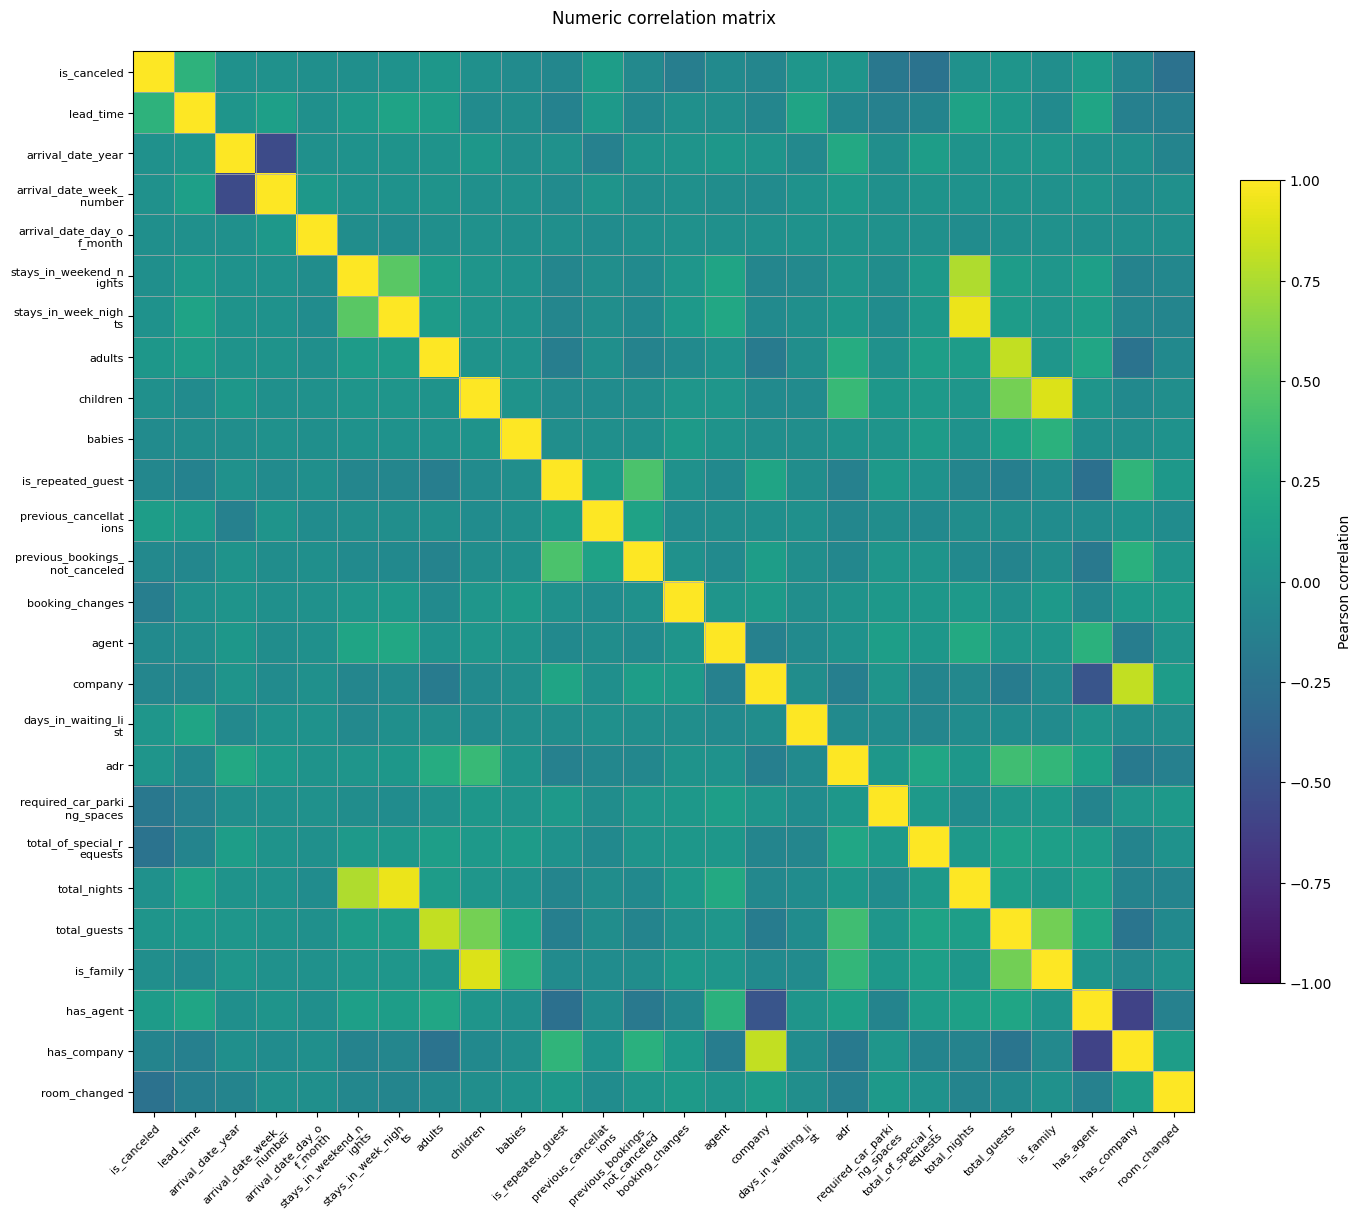

In [38]:


numeric_cols_for_corr = df.select_dtypes(include=[np.number]).columns.tolist()

corr_cols = [
    c for c in numeric_cols_for_corr
    if c not in ["is_duplicate_record"] and df[c].nunique() > 1
]

corr = df[corr_cols].corr(numeric_only=True)


target_corr = (
    corr["is_canceled"]
    .drop(labels=["is_canceled"], errors="ignore")
    .sort_values(ascending=False)
    .to_frame("correlation_with_is_canceled")
)

display(target_corr)

# Plot correlations with the target as a horizontal bar chart.
target_corr_plot = target_corr.sort_values("correlation_with_is_canceled")

fig_height = max(7, 0.36 * len(target_corr_plot))
fig, ax = plt.subplots(figsize=(11, fig_height))

target_corr_plot["correlation_with_is_canceled"].plot(kind="barh", ax=ax)

ax.axvline(0, linewidth=1)
ax.set_title("Numeric correlations with cancellation", pad=14)
ax.set_xlabel("Pearson correlation with is_canceled")
ax.set_ylabel("")
ax.tick_params(axis="y", labelsize=9)
ax.tick_params(axis="x", labelsize=9)

plt.tight_layout()
plt.show()

# Full numeric correlation matrix, made larger and with wrapped labels.
labels = [textwrap.fill(col, width=18) for col in corr.columns]
n = len(corr.columns)

fig_width = max(16, 0.70 * n)
fig_height = max(14, 0.65 * n)

fig, ax = plt.subplots(figsize=(fig_width, fig_height))

im = ax.imshow(corr, aspect="equal", vmin=-1, vmax=1)
cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.04)
cbar.set_label("Pearson correlation", rotation=90)

ax.set_xticks(np.arange(n))
ax.set_yticks(np.arange(n))

ax.set_xticklabels(labels, rotation=45, ha="right", rotation_mode="anchor", fontsize=8)
ax.set_yticklabels(labels, fontsize=8)

ax.set_title("Numeric correlation matrix", pad=20)

# Thin gridlines make the matrix easier to scan.
ax.set_xticks(np.arange(-0.5, n, 1), minor=True)
ax.set_yticks(np.arange(-0.5, n, 1), minor=True)
ax.grid(which="minor", linewidth=0.5)
ax.tick_params(which="minor", bottom=False, left=False)

plt.subplots_adjust(left=0.27, bottom=0.29, right=0.90, top=0.92)
plt.show()


###  Feature set for modeling


From our main model, we should generally exclude

- `is_canceled`: the target.
- `reservation_status`: data leakage.
- `reservation_status_date`: data leakage.
- `deposit_type`: Odd behaviour (see above).
- `is_duplicate_record`: this is a cleaning/audit flag, not a real booking feature.

For at-booking-only model, we should exclude

- `assigned_room_type`: likely assigned after booking.
- `room_changed`: derived from reserved vs assigned room.
- `booking_changes`: not available at initial booking.
.


In [39]:
target_col = "is_canceled"

strict_leakage_cols = [
    "reservation_status",
    "reservation_status_date",
]

post_booking_cols = [
    "assigned_room_type",
    "room_changed",
    "booking_changes",
]

problematic_or_audit_cols = [
    "deposit_type",
    "is_duplicate_record",
]

# Any manually created bin columns are EDA helpers, not raw customer/reservation features.
eda_helper_cols = [
    c for c in df.columns
    if c.endswith("_bin") or c in ["waiting_list_bin"]
]

exclude_conservative = (
    [target_col]
    + strict_leakage_cols
    + post_booking_cols
    + problematic_or_audit_cols
    + eda_helper_cols
)

# Deduplicate while preserving order.
exclude_conservative = list(dict.fromkeys([c for c in exclude_conservative if c in df.columns]))

X_conservative = df.drop(columns=exclude_conservative)
y = df[target_col].copy()

print("Conservative excluded columns:")
display(exclude_conservative)

print("Conservative X shape:", X_conservative.shape)
print("Target shape:", y.shape)

display(X_conservative.head())


Conservative excluded columns:


['is_canceled',
 'reservation_status',
 'reservation_status_date',
 'assigned_room_type',
 'room_changed',
 'booking_changes',
 'deposit_type',
 'is_duplicate_record',
 'lead_time_bin',
 'adr_bin',
 'total_nights_bin',
 'total_guests_bin',
 'waiting_list_bin',
 'special_requests_bin',
 'parking_spaces_bin',
 'previous_cancellations_bin',
 'previous_not_canceled_bin']

Conservative X shape: (118563, 32)
Target shape: (118563,)


,hotel,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,...,customer_type,adr,required_car_parking_spaces,total_of_special_requests,arrival_date,total_nights,total_guests,is_family,has_agent,has_company
0,Resort Hotel,7,2015,July,27,1,0,1,1,0,...,Transient,75.0,0,0,2015-07-01,1,1,0,0,0
1,Resort Hotel,13,2015,July,27,1,0,1,1,0,...,Transient,75.0,0,0,2015-07-01,1,1,0,1,0
2,Resort Hotel,14,2015,July,27,1,0,2,2,0,...,Transient,98.0,0,1,2015-07-01,2,2,0,1,0
3,Resort Hotel,14,2015,July,27,1,0,2,2,0,...,Transient,98.0,0,1,2015-07-01,2,2,0,1,0
4,Resort Hotel,0,2015,July,27,1,0,2,2,0,...,Transient,107.0,0,0,2015-07-01,2,2,0,0,0


Possible sensitivity check datasets:

1. Conservative at-booking model: Excludes leakage, post-booking variables, `deposit_type`, and duplicate audit flags.

2. At-booking with `deposit_type`: Same as conservative, but includes `deposit_type`. 

3. Pre-arrival model: Allow all variables observed before arrival (eg.`booking_changes`)

4. Duplicates model: dropping exact duplicate rows or rows flagged by `is_duplicate_record`.


In [40]:
# Feature-set variants

exclude_with_deposit = [
    c for c in exclude_conservative
    if c != "deposit_type"
]

X_with_deposit = df.drop(columns=[c for c in exclude_with_deposit if c in df.columns])

df_no_exact_duplicates = df.drop_duplicates().copy()
X_no_exact_duplicates = df_no_exact_duplicates.drop(
    columns=[c for c in exclude_conservative if c in df_no_exact_duplicates.columns]
)
y_no_exact_duplicates = df_no_exact_duplicates[target_col]

if "is_duplicate_record" in df.columns:
    df_no_flagged_duplicates = df[df["is_duplicate_record"] == 0].copy()
    X_no_flagged_duplicates = df_no_flagged_duplicates.drop(
        columns=[c for c in exclude_conservative if c in df_no_flagged_duplicates.columns]
    )
    y_no_flagged_duplicates = df_no_flagged_duplicates[target_col]
else:
    df_no_flagged_duplicates = None

feature_set_summary = pd.DataFrame({
    "feature_set": [
        "conservative",
        "with_deposit_type",
        "exact_duplicates_removed",
        "duplicate_flag_removed"
    ],
    "rows": [
        len(X_conservative),
        len(X_with_deposit),
        len(X_no_exact_duplicates),
        len(X_no_flagged_duplicates) if df_no_flagged_duplicates is not None else np.nan
    ],
    "features": [
        X_conservative.shape[1],
        X_with_deposit.shape[1],
        X_no_exact_duplicates.shape[1],
        X_no_flagged_duplicates.shape[1] if df_no_flagged_duplicates is not None else np.nan
    ],
    "cancel_rate": [
        y.mean(),
        y.mean(),
        y_no_exact_duplicates.mean(),
        y_no_flagged_duplicates.mean() if df_no_flagged_duplicates is not None else np.nan
    ]
})

display(feature_set_summary)


,feature_set,rows,features,cancel_rate
0,conservative,118563,32,0.372587
1,with_deposit_type,118563,33,0.372587
2,exact_duplicates_removed,86637,32,0.276845
3,duplicate_flag_removed,78503,32,0.264168


### EDA conclusions and project conclusion


This project focuses on hotel booking cancellations using customer and reservation features. 

The EDA suggests that cancellation behavior is not random. Several customer and reservation features are y associated with cancellation risk. In particular, cancellation rates differ strongly by hotel type, lead time, market segment, distribution channel, customer type, previous cancellation history, special requests, and some reservation characteristics.

However, some variables are not legitimate predictors for an at-booking cancellation model because they either reveal the outcome directly or are only known after the booking has progressed.

### Important EDA findings summary

City Hotel bookings cancel more often than Resort Hotel bookings. Longer lead times are associated with higher cancellation rates.`reservation_status` and `reservation_status_date` are leakage and must be excluded from prediction. `deposit_type = Non Refund` has an extreme cancellation rate in both raw and cleaned data.The `Non Refund` pattern is likely confounded, especially with group/offline travel-agent processes. Duplicates are numerous and might be handled through sensitivity analysis. Variables such as `room_changed` and `assigned_room_type` are likely post-booking information and should be excluded.

### Modeling 

The project could be: Predicting whether a hotel booking will be canceled using customer and reservation information available at the time of booking.


In [41]:
# Uncomment to export modeling datasets.

# output_dir = Path("eda_outputs")
# output_dir.mkdir(exist_ok=True)

# model_df_conservative = X_conservative.copy()
# model_df_conservative[target_col] = y

# model_df_conservative.to_csv(output_dir / "hotel_bookings_model_conservative.csv", index=False)

# print("Exported:", output_dir / "hotel_bookings_model_conservative.csv")
